In [1]:
import pandas as pd
from glob import glob
import os
import matplotlib.pyplot as plt
from scipy import ndimage
import skimage as sk
import numpy as np
from PIL import Image
import math
import napari
import SimpleITK as sitk

In [2]:
def detect_cardinal_point(
        pad_img_bbox, 
        grey_value, 
        name):
    """
    Detect the centroid of a cardinal point marker by its grey value.
    
    Returns (x, y) in pixel coordinates, or None if not found.
    """
    
    # Create binary mask for this grey value using a tolerance of 0.5.
    # Exact equality fails when floating-point representation introduces small
    # errors (e.g. 1.0 stored as 0.9999...).  A tolerance < 0.5 is safe for
    # integer-labelled images because adjacent labels always differ by >= 1.
    gv = grey_value
    lower = gv - 0.5
    upper = gv + 0.5
    mask = (pad_img_bbox >= lower) & (pad_img_bbox <= upper)
        
    if not mask.any():
        print(f"  WARNING: No pixels found for grey value {grey_value} in {name}")
        return None
    
    # Label connected components and get centroid
    labeled_img = sk.measure.label(mask.astype(np.uint8))
    props = sk.measure.regionprops(labeled_img)
    if not props:
        print(f"  WARNING: No connected components found for grey value {grey_value} in {name}")
        return None

    largest = max(props, key=lambda p: p.area)
    cy, cx = largest.centroid
    return np.array([cy, cx], dtype=float)  # return as (y,x)

def get_cardinal_points(
        pad_img_bbox,
        name,
        grey_value_df,
        directions=None
        ):
    """
    Extract one or more cardinal points from an image.

    Parameters
    ----------
    direction:
        Either a single direction string (e.g., 'north') or an iterable of
        directions (e.g., ('north', 'east')).

    Returns
    -------
    dict[str, np.ndarray]
        Keys are directions and values are (y,x) arrays (float).
    """
    points = {'north':[],
                'east':[]}
    if directions == None:
        directions = ['north', 'east']
    for direction in directions:
        grey = grey_value_df.loc[grey_value_df['Mask_IDs'] == direction, 'Mask_Grey_Value'].values[0]
        #print(f'Grey value for {d} is {grey}')
        pt = detect_cardinal_point(pad_img_bbox, grey, name)
        if pt is None:
            raise ValueError(f"Could not find '{direction}' point with grey value {grey} in {name}")
        points[direction] = pt
        print(f"  {direction}: pixel (y,x) ({pt[0]:.1f}, {pt[1]:.1f})")
    return points

def rotate_array_around_center(
        arr, 
        angle_degrees, 
        centroid, 
        reshape=True,
        order=0,
        mode='nearest',
        prefilter=False):
    """
    Rotates an array around a specific center coordinate.

    Args:
        points (np.ndarray): An N x 2 array of (x, y) coordinates.
        angle_degrees (float): The rotation angle in degrees (counter-clockwise).
        center (tuple): The (x0, y0) coordinates of the rotation center.

    Returns:
        np.ndarray: The array of rotated array.
    """
    # Convert angle to radians
    c_y,c_x = arr.shape[0]//2,arr.shape[1]//2
    t_y,t_x = centroid
    s_y,s_x = c_y - t_y, c_x - t_x

    #Shift Array to new center:
    shifted_arr = ndimage.shift(arr, [s_y,s_x], mode=mode,prefilter=prefilter,order=order)

    #Rotate array around new point:
    rotated_arr = ndimage.rotate(shifted_arr, angle_degrees, reshape=reshape,order=order, mode=mode, prefilter=prefilter)
        
    return rotated_arr  

def calculate_angle_and_flip(
        points,
        name,
        grey_value_df,
        mask_arr,
        ):
    """
    Calculates the angle (in degrees) between three points.

    north coord : [x, y]
    mask centroid : [x, y] (vertex)
    relative north over mask centroid  : [x, y]
    """
    ny, nx = points['north']
    north_coord = (nx, ny)

    tissue_pixels = np.argwhere(mask_arr == 3)
    if tissue_pixels.size == 0:
        raise ValueError("ORIENTATION_MISMATCH: no tissue area found.")
    #Use centroid of mask to calculate angle of rotation
    cy, cx = tissue_pixels.mean(axis=0)  # (y, x)
    mask_centroid = (cx,cy)
    #Use north over mask centroid
    relative_north = (cx, 0)

    #Get side of image north is on
    if nx < mask_arr.shape[1]//2:
        side = 'left'
    elif nx > mask_arr.shape[1]//2:
        side = 'right'
    else:
        side = 'midline'

    #if north on mid line, determine if on the top or bottom of image:
    rotate = None
    if side == 'midline':
        if ny < mask_arr.shape[0]//2:
            rotate = None
        if ny > mask_arr.shape[0]//2:
            rotate = 180
    # Convert points to numpy arrays
    p1 = np.array(north_coord)
    p2 = np.array(mask_centroid)
    p3 = np.array(relative_north)

    # Create vectors from the vertex (p2) to the other points
    v1 = p1 - p2
    v2 = p3 - p2

    # Calculate the dot product and magnitudes
    dot_product = np.dot(v1, v2)
    magnitude_v1 = np.linalg.norm(v1)
    magnitude_v2 = np.linalg.norm(v2)

    # Calculate the cosine of the angle
    # Ensure the denominator is not zero to avoid division errors
    if magnitude_v1 == 0 or magnitude_v2 == 0:
        raise ValueError(f"ORIENTATION_MISMATCH: zero-length vector in {name} - north point coincides with mask centroid")
    cosine_angle = dot_product / (magnitude_v1 * magnitude_v2)

    # Handle floating point errors that might result in a value slightly outside [-1, 1]
    cosine_angle = np.clip(cosine_angle, -1.0, 1.0)

    # Calculate the angle in radians and convert to degrees
    angle_rad = np.arccos(cosine_angle)
    angle_deg = np.degrees(angle_rad)

    if side == 'left':
        angle_deg = -angle_deg
        angle_rad = np.deg2rad(angle_deg)
    elif side == 'right':
        angle_deg = angle_deg
        angle_rad = np.deg2rad(angle_deg)
    elif rotate:
        angle_deg = rotate
        angle_rad = np.deg2rad(angle_deg)

    rotated_arr = rotate_array_around_center(mask_arr,angle_deg,centroid=(cy,cx))
    try:
        rotated_points = get_cardinal_points(rotated_arr,name,grey_value_df,['east'])
    except ValueError as e:
        raise ValueError(f"CARDINAL_POINT_FAILURE: {e}")

    new_east = rotated_points['east']
    _, ex = new_east

    if ex > rotated_arr.shape[1]//2:
        flip = 'hortizontal'
    else:
        flip = None

    print(f'Detected Rotation(degrees): {angle_deg}')
    print(f'Detected Rotation(radians): {angle_rad}')
    print(f'Detected Flip: {flip}')
    return angle_deg, angle_rad, flip

def load_sitk_imgs(map_region,pad_mask_bbox,spacing):
    """ Convert array to 32bit float and then to sitk image for registration """
    bitdepth_map = np.array(map_region).astype(np.float32)
    sitk_fixed = sitk.GetImageFromArray(bitdepth_map)
    sitk_fixed.SetSpacing(spacing)
    bitdepth_mask = np.array(pad_mask_bbox).astype(np.float32)
    sitk_moving = sitk.GetImageFromArray(bitdepth_mask)
    sitk_moving.SetSpacing(spacing)
    return sitk_fixed, sitk_moving

def get_bbox_alignment_points(sitk_image,point_key):
    """Extract physical centroid of the mask region."""
    binary = sitk.BinaryThreshold(
        sitk_image,
        lowerThreshold= 0.5,
        upperThreshold= 255.0,
        insideValue=1,
        outsideValue=0
    )
    label_stats = sitk.LabelShapeStatisticsImageFilter()
    label_stats.Execute(binary)
    if 1 not in label_stats.GetLabels():
        raise ValueError("No mask found — check your threshold.")
    bbox = label_stats.GetBoundingBox(1)
    points = (bbox[2]+bbox[0],bbox[3]+bbox[1])
    return bbox, points  # returns physical coords

def get_mask_centroid(sitk_image):
        """Extract physical centroid of the mask region."""
        binary = sitk.BinaryThreshold(
            sitk_image,
            lowerThreshold= 0.5,
            upperThreshold= 255.0,
            insideValue=1,
            outsideValue=0
        )
        label_stats = sitk.LabelShapeStatisticsImageFilter()
        label_stats.Execute(binary)
        if 1 not in label_stats.GetLabels():
            raise ValueError("No mask found — check your threshold.")
        return label_stats.GetCentroid(1)  # returns physical coords

def get_alignment_transform(sitk_moving, sitk_fixed, point_key=None):
    """
    Build a translation transform that maps the fixed mask centroid to the
    moving mask centroid.  SimpleITK resampling uses the transform in the
    fixed→moving direction: T(p) = p + offset, so T(fixed_centroid) =
    moving_centroid requires offset = moving_centroid - fixed_centroid.
    """
    _,fixed_point  = get_bbox_alignment_points(sitk_fixed,point_key)
    _,moving_point = get_bbox_alignment_points(sitk_moving,point_key)

    translation = sitk.TranslationTransform(sitk_moving.GetDimension())
    offset = [m - f for f, m in zip(fixed_point, moving_point)]
    translation.SetOffset(offset)
    return translation

def resample(sitk_img, transform):
    resampled_img = sitk.Resample(
            sitk_img, transform,
            sitk.sitkNearestNeighbor, 0.0, sitk_img.GetPixelID())
    return resampled_img

def apply_flip_rotation(sitk_moving, sitk_fixed, flip=None, rads=None, angle_degrees=None):
    """
    Build a composite pre-alignment transform (fixed→moving, backward convention).

    Forward orientation operations applied to the moving image:
        1. Rotate CCW by angle_degrees around moving mask centroid → north to top
        2. Flip horizontally around moving mask centroid (if needed) → east to left
        3. Translate moving centroid to fixed centroid

    Backward (fixed→moving) composite undoes these in reverse order.
    SimpleITK CompositeTransform applies transforms last-added → first-applied,
    so we add transforms in reverse application order:
        add 1st (applied last): rotation by -rads  (un-rotate)
        add 2nd (applied 2nd):  horizontal flip    (un-flip, self-inverse)
        add 3rd (applied 1st):  centroid alignment (un-translate)

    All rotation and flip transforms are centred on the physical centroid of the
    moving mask (not the image centre) so that the centroid stays fixed under
    rotation and flip, guaranteeing the aligned centroid remains within the
    moving image bounds.
    """
    composite_transform = sitk.CompositeTransform(2)

    # Centroid of the moving mask in physical coordinates — used as the centre
    # for both rotation and flip so that those transforms leave the centroid fixed.
    moving_centroid = get_mask_centroid(sitk_moving)

    if rads is not None:
        print(f"  Applying rotation: {angle_degrees:.2f} degrees")
        rotation_transform = sitk.Euler2DTransform()
        rotation_transform.SetCenter(moving_centroid)
        rotation_transform.SetAngle(rads)
        composite_transform.AddTransform(rotation_transform)

    if flip is not None:
        print(f"  Applying flip: {flip}")
        flip_transform = sitk.AffineTransform(sitk_moving.GetDimension())
        flip_transform.SetCenter(moving_centroid)
        flip_transform.SetMatrix([-1,  0, 0,  1])   # horizontal flip: x → -(x-cx)+cx
        composite_transform.AddTransform(flip_transform)


    resampled = resample(sitk_moving,composite_transform)

    # bbox alignment: translate fixed point → moving point.
    transform = get_alignment_transform(resampled, sitk_fixed)
    composite_transform.AddTransform(transform)

    if flip is None and rads is None:
        print("  No flip or rotation applied.")

    return composite_transform

def to_distance_map(sitk_img):
    """Convert binary mask to signed Maurer distance map for smoother optimization."""
    binary = sitk.BinaryThreshold(sitk_img, lowerThreshold=0.5, upperThreshold=255.0,
                                insideValue=1, outsideValue=0)
    return sitk.SignedMaurerDistanceMap(
        sitk.Cast(binary, sitk.sitkUInt8),
        insideIsPositive=True,
        squaredDistance=False,
        useImageSpacing=True
    )

def refine_registration(
                        sitk_moving,
                        sitk_fixed,
                        composite_transform
                        ):
    # save_path_hdf = os.path.join(data_path,tissue_id,'transformation_files','hdf')
    # save_file_hdf = os.path.join(save_path_hdf,f"TF_hdf_{name}_{tissue_id}.hdf")
    # os.makedirs(save_path_hdf,exist_ok=True)

    moving_dist = to_distance_map(sitk_moving)
    fixed_dist = to_distance_map(sitk_fixed)

    fixed_mask_sitk = sitk.BinaryThreshold(
        sitk_fixed,
        lowerThreshold=0.5,
        upperThreshold=255.0,
        insideValue=1,
        outsideValue=0
    )

    fine = sitk.TranslationTransform(2)
    method = sitk.ImageRegistrationMethod()
    method.SetMetricFixedMask(fixed_mask_sitk)
    method.SetMetricSamplingStrategy(method.RANDOM)
    method.SetMetricSamplingPercentage(0.2)
    method.SetMetricAsJointHistogramMutualInformation()
    method.MetricUseFixedImageGradientFilterOff()
    method.SetMovingInitialTransform(composite_transform)
    method.SetInitialTransform(fine, inPlace=True)
    method.SetOptimizerAsGradientDescent(
        learningRate=1.0,
        numberOfIterations=500,
        convergenceMinimumValue=1e-6,
        convergenceWindowSize=20
    )
    method.SetOptimizerScalesFromPhysicalShift()
    method.SetShrinkFactorsPerLevel(shrinkFactors=[2, 1])
    method.SetSmoothingSigmasPerLevel(smoothingSigmas=[1, 0])
    method.SmoothingSigmasAreSpecifiedInPhysicalUnitsOn()
    method.SetInterpolator(sitk.sitkLinear)
    method.Execute(fixed_dist, moving_dist)

    print(f"  Registering...")
    print(f"metric: {method.GetMetricValue():.6f}")

    full_composite = sitk.CompositeTransform(2)
    full_composite.AddTransform(composite_transform)
    full_composite.AddTransform(fine)

    #save transform as mat and csv
    full_composite.FlattenTransform()
    # full_composite.WriteTransform(save_file_hdf)
    return full_composite

# Testing bounding box approach
Use corners or midpoints of bounding boxes from tissue masks and map regions to set up alignment instead of centroid (need to use a key to specify which part of the bounding box to use)

In [3]:
mask_test_r1 = sk.io.imread(r"Pipeline_Test\Tissue\padded_cropped_mask_239511.png")
img_test_r1 = sk.io.imread(r"Pipeline_Test\Tissue\padded_cropped_239511.png")

mask_test_r2 = sk.io.imread(r"Pipeline_Test\Tissue\padded_cropped_mask_239512.png")
img_test_r2 = sk.io.imread(r"Pipeline_Test\Tissue\padded_cropped_239512.png")

mask_test_r3 = sk.io.imread(r"Pipeline_Test\Tissue1\padded_cropped_mask_239513.png")
img_test_r3 = sk.io.imread(r"Pipeline_Test\Tissue1\padded_cropped_239513.png")

mask_test_r4 = sk.io.imread(r"Pipeline_Test\Tissue2\padded_cropped_mask_239513.png")
img_test_r4 = sk.io.imread(r"Pipeline_Test\Tissue2\padded_cropped_239513.png")

mask_test_r5 = sk.io.imread(r"Pipeline_Test\Tissue1\padded_cropped_mask_239514.png")
img_test_r5 = sk.io.imread(r"Pipeline_Test\Tissue1\padded_cropped_239514.png")

mask_test_r6 = sk.io.imread(r"Pipeline_Test\Tissue2\padded_cropped_mask_239514.png")
img_test_r6 = sk.io.imread(r"Pipeline_Test\Tissue2\padded_cropped_239514.png")

mask_test_r7 = sk.io.imread(r"Pipeline_Test\Tissue\padded_cropped_mask_239515.png")
img_test_r7 = sk.io.imread(r"Pipeline_Test\Tissue\padded_cropped_239515.png")

mask_test_r8 = sk.io.imread(r"Pipeline_Test\Tissue\padded_cropped_mask_239516.png")
img_test_r8 = sk.io.imread(r"Pipeline_Test\Tissue\padded_cropped_239516.png")

map_test = np.array(Image.open(r"Pipeline_Test\Maps\SD401_Left.png").convert('L'))

In [ ]:
viewer = napari.view_image(map_test)
viewer.add_image(mask_test_r1,name='R1')
viewer.add_image(mask_test_r2,name='R2')
viewer.add_image(mask_test_r3,name='R3')
viewer.add_image(mask_test_r4,name='R4')
viewer.add_image(mask_test_r5,name='R5')
viewer.add_image(mask_test_r6,name='R6')
viewer.add_image(mask_test_r7,name='R7')
viewer.add_image(mask_test_r8,name='R8')

In [4]:
map_R1 = (map_test == 160)*map_test
map_R2 = (map_test == 172)*map_test
map_R3 = (map_test == 88)*map_test
map_R4 = (map_test == 98)*map_test
map_R5 = (map_test == 52)*map_test
map_R6 = (map_test == 62)*map_test
map_R7 = (map_test == 79)*map_test
map_R8 = (map_test == 44)*map_test

In [ ]:
df = pd.read_csv(r"Annotation_Key.csv",dtype=str)
df_WT = df[df['Genotype'] == 'WT']
df_SD401_L = df[df['MapBase']=='SD401-Left']
df_SD401_L.head(n=10)

In [ ]:
map_options = df_WT['MapBase'].unique().tolist()
map_options

In [ ]:
viewer = napari.view_image(map_test)
viewer.add_image(img_test_r1,name="R1")
viewer.add_image(img_test_r2,name="R2")
viewer.add_image(img_test_r3,name="R3")


In [5]:
grey_value_df = pd.read_csv(r'Maps\PNGsForReg\HexColorMappingKey.csv',dtype=str)
grey_value_df['Map_Grey_value'] = grey_value_df['Map_Grey_value'].astype(float)
grey_value_df['Mask_Grey_Value'] = grey_value_df['Mask_Grey_Value'].astype(float)

In [6]:
def plot_registered_tissues(sitk_imgs,map_array,map_regions,transforms):
    #save_img = os.path.join(save_path,f'{animal_id}_{gland}_Registered_Overlay_all_regions.png')
    color_list = ['Purples', 'Blues', 'Greens', 'Oranges', 'Reds',
                      'YlOrBr', 'YlOrRd', 'OrRd', 'PuRd', 'RdPu', 'BuPu',
                      'GnBu', 'PuBu', 'YlGnBu', 'PuBuGn', 'BuGn', 'YlGn']
    _, axes = plt.subplots()
    axes.imshow(map_array, cmap="Greys")
    i = 0
    for img, region, transform in zip(sitk_imgs,map_regions,transforms):
        resampled = sitk.Resample(
            img, region, transform,
            sitk.sitkNearestNeighbor, 0.0, img.GetPixelID()
        )
        resampled_arr  = sitk.GetArrayFromImage(resampled)
        masked_img = np.ma.masked_where(resampled_arr==0,resampled_arr)
        axes.imshow(masked_img,cmap=color_list[i % len(color_list)],alpha=0.7)
        i+=1
    plt.tight_layout()
    #plt.savefig(save_img, dpi=600)
    #plt.close()
    plt.show()


In [7]:
def get_bbox_corners_physical(sitk_image):
    """
    Return the four corners of the mask bounding box in physical coordinates.

    The bounding box is derived from the binary mask (any pixel > 0.5).
    Corner keys: 'top_left', 'top_right', 'bottom_left', 'bottom_right'
    where top = smaller row index (lower y in image coords).

    Returns
    -------
    dict[str, tuple[float, float]]
        Physical (x, y) coordinate for each corner.
    """
    binary = sitk.BinaryThreshold(
        sitk_image,
        lowerThreshold=0.5,
        upperThreshold=255.0,
        insideValue=1,
        outsideValue=0
    )
    label_stats = sitk.LabelShapeStatisticsImageFilter()
    label_stats.Execute(binary)
    if 1 not in label_stats.GetLabels():
        raise ValueError("No mask found in image — check threshold.")

    # GetBoundingBox returns (start_x, start_y, size_x, size_y) in index coords
    bbox = label_stats.GetBoundingBox(1)
    x0, y0, sx, sy = bbox
    x1, y1 = x0 + sx, y0 + sy  # exclusive end indices
    #mid points of all sides
    mx = x0 + (sx//2)
    my = y0 + (sy//2)

    corners_idx = {
        'top_left':     (x0, y0),
        'top_right':    (x1, y0),
        'bottom_left':  (x0, y1),
        'bottom_right': (x1, y1),
        'top_middle' : (mx, y0),
        'bottom_middle' : (mx,y1),
        'right_middle' : (x1,my),
        'left_middle' : (x0,my)
    }
    return {
        key: sitk_image.TransformIndexToPhysicalPoint(idx)
        for key, idx in corners_idx.items()
    }


def get_oriented_moving(sitk_moving, moving_centroid, rads, flip):
    """
    Resample the moving image using the *forward* orientation (rotation + flip)
    so that the mask sits in its oriented position within the same pixel grid.

    The orientation composite is built as a backward (fixed→moving) transform;
    its inverse is the forward (moving→oriented) transform used here.

    Parameters
    ----------
    sitk_moving     : SimpleITK image of the padded tissue mask
    moving_centroid : (x, y) physical centroid of the moving mask
    rads            : rotation angle in radians (from calculate_angle_and_flip)
    flip            : 'horizontal' if a flip is needed, else None

    Returns
    -------
    oriented_moving : SimpleITK image with the mask in its oriented position
    """
    orientation_only = sitk.CompositeTransform(2)

    if rads is not None:
        rot = sitk.Euler2DTransform()
        rot.SetCenter(moving_centroid)
        rot.SetAngle(rads)
        orientation_only.AddTransform(rot)

    if flip is not None:
        flp = sitk.AffineTransform(2)
        flp.SetCenter(moving_centroid)
        flp.SetMatrix([-1, 0, 0, 1])
        orientation_only.AddTransform(flp)

    if orientation_only.GetNumberOfTransforms() == 0:
        return sitk_moving  # no orientation needed

    forward_orientation = orientation_only.GetInverse()
    oriented_moving = sitk.Resample(
        sitk_moving,
        sitk_moving,
        forward_orientation,
        sitk.sitkNearestNeighbor,
        0.0,
        sitk_moving.GetPixelID()
    )
    return oriented_moving


def build_bbox_corner_transform(sitk_moving, sitk_fixed, rads, flip, angle_degrees, corner=None):
    """
    Build a composite pre-alignment transform (backward / fixed→moving convention)
    that orients the moving image and then translates it so that the specified
    bounding-box corner of the oriented moving mask aligns with the same corner
    of the fixed mask.

    Parameters
    ----------
    sitk_moving   : SimpleITK image of the padded tissue mask
    sitk_fixed    : SimpleITK image of the map region
    rads          : rotation angle in radians
    flip          : 'horizontal' or None
    angle_degrees : rotation angle in degrees (for logging)
    corner        : which bbox point to align; one of
                    'top_left', 'top_right', 'bottom_left', 'bottom_right', 
                    'top_middle', 'bottom_middle', 'right_middle', 'left_middle'

    Returns
    -------
    composite_transform : sitk.CompositeTransform (fixed→moving, backward)
    """
    composite_transform = sitk.CompositeTransform(2)
    moving_centroid = get_mask_centroid_sitk(sitk_moving)

    if rads is not None:
        print(f"  Applying rotation: {angle_degrees:.2f} degrees")
        rot = sitk.Euler2DTransform()
        rot.SetCenter(moving_centroid)
        rot.SetAngle(rads)
        composite_transform.AddTransform(rot)

    if flip is not None:
        print(f"  Applying flip: {flip}")
        flp = sitk.AffineTransform(2)
        flp.SetCenter(moving_centroid)
        flp.SetMatrix([-1, 0, 0, 1])
        composite_transform.AddTransform(flp)

    # Resample moving with forward orientation to find its oriented bbox corners
    oriented_moving = get_oriented_moving(sitk_moving, moving_centroid, rads, flip)

    moving_corners = get_bbox_corners_physical(oriented_moving)
    fixed_corners  = get_bbox_corners_physical(sitk_fixed)

    mc = moving_corners[corner]
    fc = fixed_corners[corner]
    print(f"  Oriented moving {corner} (physical): {mc}")
    print(f"  Fixed           {corner} (physical): {fc}")

    # Backward translation: T(p) = p + offset, so T(fc) = mc requires offset = mc - fc
    offset = [m - f for m, f in zip(mc, fc)]
    translation = sitk.TranslationTransform(2)
    translation.SetOffset(offset)
    composite_transform.AddTransform(translation)

    if flip is None and rads is None:
        print("  No flip or rotation applied.")

    return composite_transform

def get_mask_centroid_sitk(sitk_image):
    """Return the physical centroid of the binary mask in a SimpleITK image."""
    binary = sitk.BinaryThreshold(
        sitk_image,
        lowerThreshold=0.5,
        upperThreshold=255.0,
        insideValue=1,
        outsideValue=0
    )
    label_stats = sitk.LabelShapeStatisticsImageFilter()
    label_stats.Execute(binary)
    if 1 not in label_stats.GetLabels():
        raise ValueError("No mask found — check your threshold.")
    return label_stats.GetCentroid(1)  # returns (x, y) physical coords


def load_sitk_imgs(map_region,pad_mask_bbox,spacing):
    """ Convert array to 32bit float and then to sitk image for registration """
    bitdepth_map = np.array(map_region).astype(np.float32)
    sitk_fixed = sitk.GetImageFromArray(bitdepth_map)
    sitk_fixed.SetSpacing(spacing)
    bitdepth_mask = np.array(pad_mask_bbox).astype(np.float32)
    sitk_moving = sitk.GetImageFromArray(bitdepth_mask)
    sitk_moving.SetSpacing(spacing)
    return sitk_fixed, sitk_moving

In [10]:
def to_distance_map(sitk_img):
    """Convert binary mask to signed Maurer distance map for smoother optimization."""
    binary = sitk.BinaryThreshold(sitk_img, lowerThreshold=0.5, upperThreshold=255.0,
                                insideValue=1, outsideValue=0)
    return sitk.SignedMaurerDistanceMap(
        sitk.Cast(binary, sitk.sitkUInt8),
        insideIsPositive=True,
        squaredDistance=False,
        useImageSpacing=True
    )

def refine_registration(sitk_moving,
                        sitk_fixed,
                        composite_transform
                        ):
    #save_path_hdf = os.path.join(data_path,tissue_id,'transformation_files','hdf')
    #save_file_hdf = os.path.join(save_path_hdf,f"TF_hdf_{name}_{tissue_id}.hdf")
    #os.makedirs(save_path_hdf,exist_ok=True)

    moving_dist = to_distance_map(sitk_moving)
    fixed_dist = to_distance_map(sitk_fixed)

    fixed_mask_sitk = sitk.BinaryThreshold(
        sitk_fixed,
        lowerThreshold=0.5,
        upperThreshold=255.0,
        insideValue=1,
        outsideValue=0
    )

    fine = sitk.TranslationTransform(2)
    method = sitk.ImageRegistrationMethod()
    method.SetMetricFixedMask(fixed_mask_sitk)
    method.SetMetricSamplingStrategy(method.RANDOM)
    method.SetMetricSamplingPercentage(0.2)
    method.SetMetricAsJointHistogramMutualInformation()
    method.MetricUseFixedImageGradientFilterOff()
    method.SetMovingInitialTransform(composite_transform)
    method.SetInitialTransform(fine, inPlace=True)
    method.SetOptimizerAsGradientDescent(
        learningRate=1.0,
        numberOfIterations=500,
        convergenceMinimumValue=1e-6,
        convergenceWindowSize=20
    )
    method.SetOptimizerScalesFromPhysicalShift()
    method.SetShrinkFactorsPerLevel(shrinkFactors=[2, 1])
    method.SetSmoothingSigmasPerLevel(smoothingSigmas=[1, 0])
    method.SmoothingSigmasAreSpecifiedInPhysicalUnitsOn()
    method.SetInterpolator(sitk.sitkLinear)
    method.Execute(fixed_dist, moving_dist)

    print(f"  Registering...")
    print(f"metric: {method.GetMetricValue():.6f}")

    full_composite = sitk.CompositeTransform(2)
    full_composite.AddTransform(composite_transform)
    full_composite.AddTransform(fine)

    #save transform as mat and csv
    full_composite.FlattenTransform()
    #full_composite.WriteTransform(save_file_hdf)
    return full_composite

In [ ]:
# --- Test bbox corner alignment ---
# Assumes the following are already defined in earlier cells:
#   test          : padded tissue mask array (pad_img_bbox)
#   points        : cardinal point dict from get_cardinal_points
#   grey_value_df : grey value lookup dataframe
#   map           : map array (the full map image)
#   angle_deg, angle_rad, flip : from calculate_angle_and_flip / spliced_function

# 1. Get the map region for this tissue (set map_grey_value to the correct grey value for this tissue)
# map_grey_value = 195  # <-- replace with the correct Map_Grey_value for this tissue
# map_region = (map == map_grey_value).astype(np.uint8)
# map_region = ndimage.binary_fill_holes(map_region).astype(np.uint8) * 255

# 2. Load as SimpleITK images
sitk_fixed, sitk_moving = load_sitk_imgs(map_region_test, mask_test, spacing=(16.1, 16.1))

#get rotation/flips:
points_img = get_cardinal_points(img_test,'Test',grey_value_df)
angle_deg, angle_rad, flip = calculate_angle_and_flip(points_img,'Test',grey_value_df,img_test)

# 3. Build bbox corner alignment transform (try each corner to find best initial alignment)
for corner in ['top_left', 'top_right', 'bottom_left', 'bottom_right','top_middle', 'bottom_middle', 'right_middle', 'left_middle']:
    print(f"\n--- corner: {corner} ---")
    composite = build_bbox_corner_transform(
        sitk_moving, sitk_fixed,
        rads=angle_rad,
        flip=flip,
        angle_degrees=angle_deg,
        corner=corner
    )

    # 4. Visualise overlay
    resampled = sitk.Resample(
        sitk_moving, sitk_fixed, composite,
        sitk.sitkNearestNeighbor, 0.0, sitk_moving.GetPixelID()
    )
    fixed_arr  = sitk.GetArrayFromImage(sitk_fixed)
    moved_arr  = sitk.GetArrayFromImage(resampled)

    fig, ax = plt.subplots()
    ax.imshow(fixed_arr,  cmap='Greys')
    ax.imshow(moved_arr,  cmap='Reds', alpha=0.6)
    ax.set_title(f"Corner: {corner}")
    plt.tight_layout()
    plt.show()

In [9]:
imgs = [img_test_r1,img_test_r2,img_test_r3,img_test_r4,img_test_r5,img_test_r6,img_test_r7,img_test_r8]
masks = [mask_test_r1,mask_test_r2,mask_test_r3,mask_test_r4,mask_test_r5,mask_test_r6,mask_test_r7,mask_test_r8]
map_regions = [map_R1,map_R2,map_R3,map_R4,map_R5,map_R6,map_R7,map_R8]
corner_key = ['top_left','top_right','left_middle','left_middle','right_middle', 'right_middle','bottom_left','bottom_right']

In [11]:
transforms = []
sitk_imgs = []
sitk_regions = []
for img, mask, region, corner in zip(imgs,masks,map_regions,corner_key):
    sitk_fixed, sitk_moving = load_sitk_imgs(region, mask, spacing=(16.1, 16.1))
    sitk_imgs.append(sitk_moving)
    sitk_regions.append(sitk_fixed)
    points_img = get_cardinal_points(img,'Test',grey_value_df)
    angle_deg, angle_rad, flip = calculate_angle_and_flip(points_img,'Test',grey_value_df,img)
    composite = build_bbox_corner_transform(sitk_moving,sitk_fixed,angle_rad,flip,angle_deg,corner)
    full_transform = refine_registration(sitk_moving, sitk_fixed, composite)
    transforms.append(full_transform)

  north: pixel (y,x) (780.8, 1470.6)
  east: pixel (y,x) (458.4, 1018.7)
  east: pixel (y,x) (552.3, 470.4)
Detected Rotation(degrees): 89.95233867833664
Detected Rotation(radians): 1.569964479806019
Detected Flip: None
  Applying rotation: 89.95 degrees
  Oriented moving top_left (physical): (5683.3, 2044.7000000000003)
  Fixed           top_left (physical): (19223.4, 39074.700000000004)
  Registering...
metric: -2.057858
  north: pixel (y,x) (736.7, 1289.5)
  east: pixel (y,x) (430.7, 712.4)
  east: pixel (y,x) (827.5, 461.8)
Detected Rotation(degrees): 93.02510693505987
Detected Rotation(radians): 1.6235944030366056
Detected Flip: None
  Applying rotation: 93.03 degrees
  Oriented moving top_right (physical): (16921.100000000002, 483.00000000000006)
  Fixed           top_right (physical): (20591.9, 39074.700000000004)
  Registering...
metric: -2.274738
  north: pixel (y,x) (478.0, 558.0)
  east: pixel (y,x) (596.8, 113.0)
  east: pixel (y,x) (455.9, 377.4)
Detected Rotation(degrees)

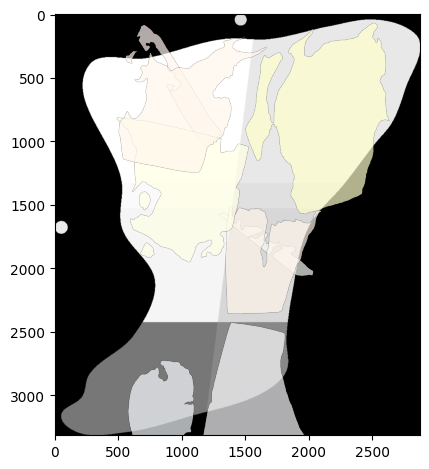

In [12]:
plot_registered_tissues(sitk_imgs,map_test,sitk_regions,transforms)